# Day 1 — Exploratory Data Analysis

## Objective

Explore the cleaned Cardiovascular Disease dataset to understand its structure, feature distributions, relationships, and target variable before building the baseline model.

## Tasks

- Load the cleaned dataset
- Inspect the dataset structure
- Analyze the target variable
- Explore numerical and categorical features
- Examine relationships between features and cardiovascular disease
- Analyze feature correlations
- Summarize the main findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cardio_cleaned.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68742 entries, 0 to 68741
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68742 non-null  int64  
 1   gender       68742 non-null  int64  
 2   height       68742 non-null  int64  
 3   weight       68742 non-null  float64
 4   ap_hi        68742 non-null  int64  
 5   ap_lo        68742 non-null  int64  
 6   cholesterol  68742 non-null  int64  
 7   gluc         68742 non-null  int64  
 8   smoke        68742 non-null  int64  
 9   alco         68742 non-null  int64  
 10  active       68742 non-null  int64  
 11  cardio       68742 non-null  int64  
 12  age_years    68742 non-null  float64
dtypes: float64(2), int64(11)
memory usage: 6.8 MB


In [4]:
df.describe()

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000,68742.000000
mean,49972.958555,1.348724,164.395042,74.123358,126.616494,81.382314,1.364799,1.226092,0.087996,0.053635,0.803381,0.494923,53.290967
std,28845.944439,0.476570,7.978866,14.306639,16.764166,9.676688,0.679027,0.572065,0.283291,0.225298,0.397445,0.499978,6.757142
min,0.000000,1.000000,100.000000,30.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.563313
25%,24997.250000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.342231
50%,50019.500000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.938398
75%,74865.750000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.381930
max,99999.000000,2.000000,207.000000,200.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.922656


## Target Variable Distribution

The target variable cardio indicates whether the patient has cardiovascular disease:

- 0: No cardiovascular disease
- 1: Cardiovascular disease

The distribution of the target variable is examined to identify whether the dataset is balanced.

In [6]:
print(df["cardio"].value_counts())
print(df["cardio"].value_counts(normalize=True) * 100)

cardio
0    34720
1    34022
Name: count, dtype: int64
cardio
0    50.507695
1    49.492305
Name: proportion, dtype: float64


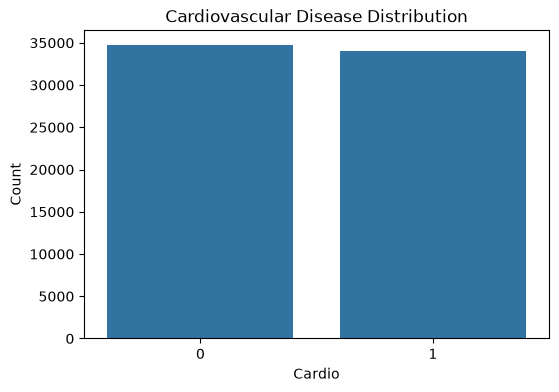

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="cardio")

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardio")
plt.ylabel("Count")
plt.show()

## Important Feature Distributions

The distributions of the main numerical features are visualized to understand their range, spread, and overall patterns before analyzing their relationship with the target variable.

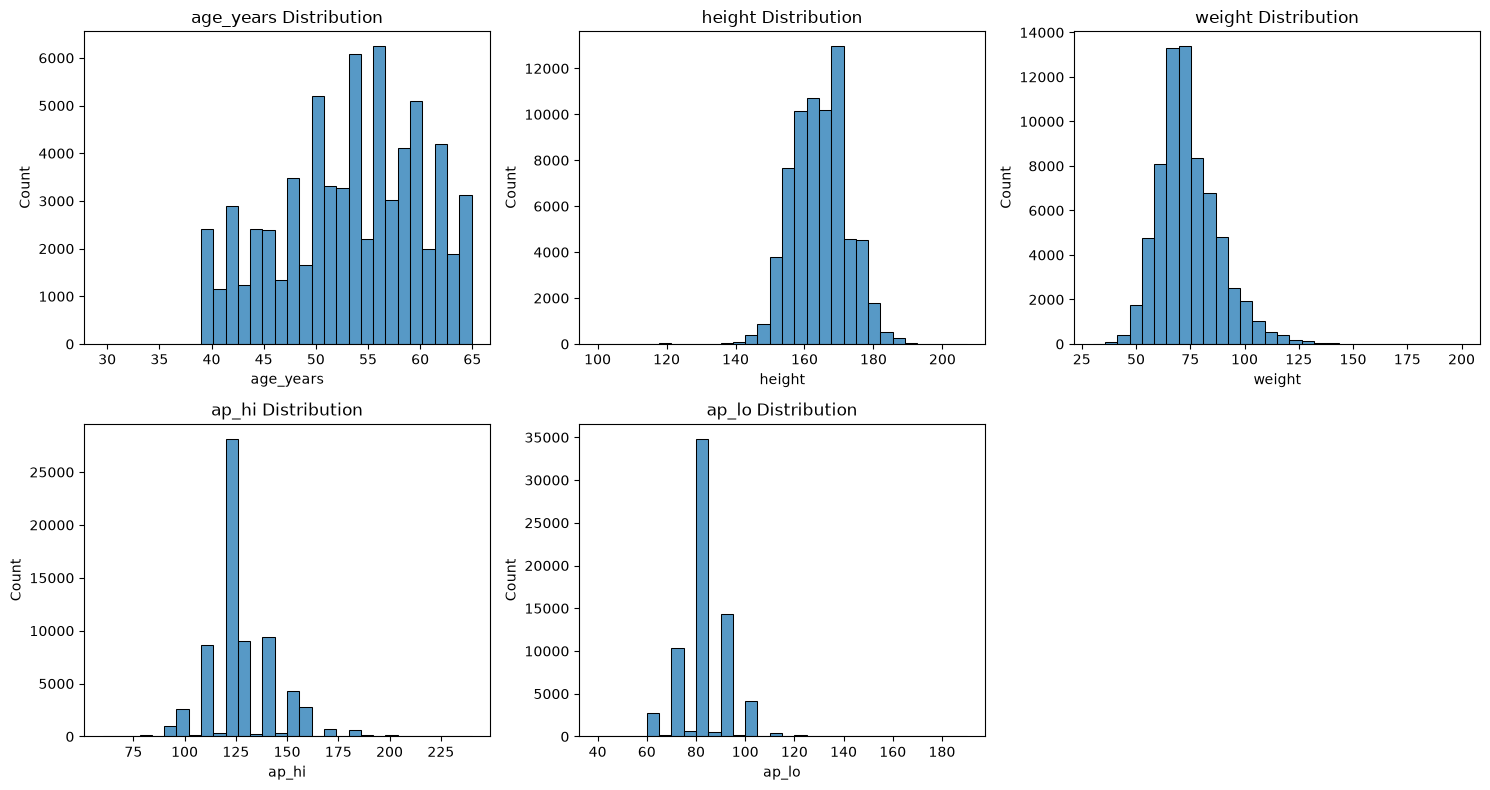

In [10]:
important_features = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, important_features):
    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        ax=ax
    )
    
    ax.set_title(f"{feature} Distribution")
    
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

## Important Features vs Cardiovascular Disease

The following visualizations explore the relationship between the most relevant features and the target variable cardio.

The selected features include age, weight, systolic blood pressure, diastolic blood pressure, and cholesterol level.

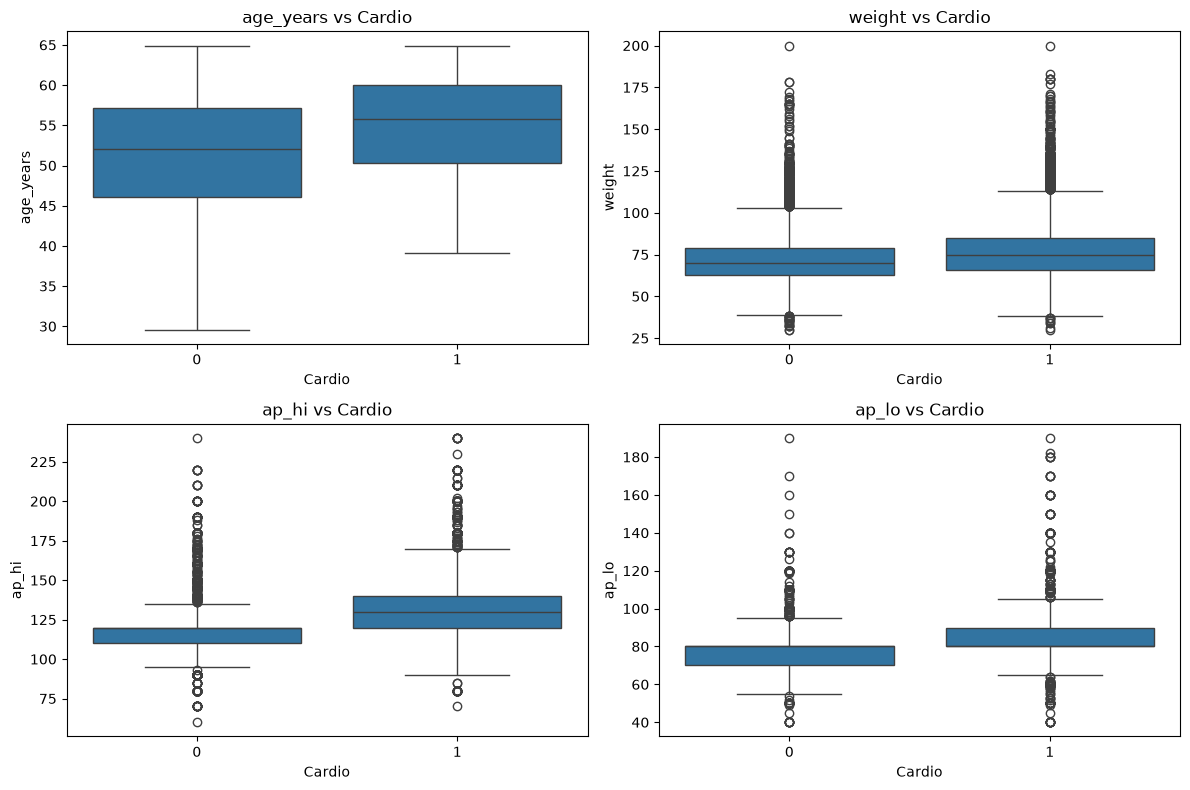

In [13]:
important_features = [
    "age_years",
    "weight",
    "ap_hi",
    "ap_lo"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flat, important_features):
    sns.boxplot(
        data=df,
        x="cardio",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} vs Cardio")
    ax.set_xlabel("Cardio")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## Categorical Feature Distributions

The distributions of the categorical and binary features are visualized to understand the composition of the dataset.

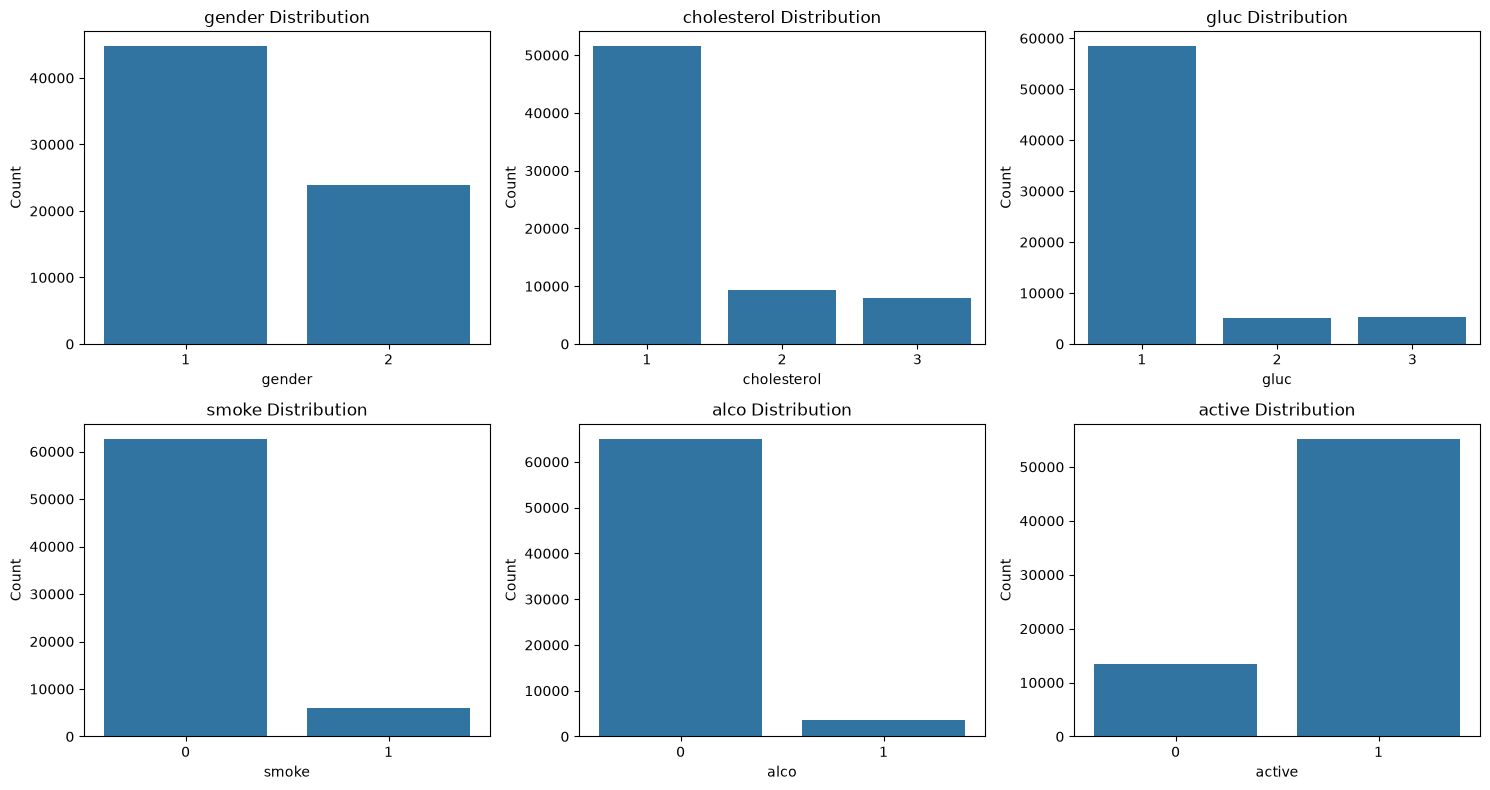

In [11]:
categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Categorical Features vs Cardiovascular Disease

The relationship between categorical features and the target variable cardio is examined to identify differences in cardiovascular disease prevalence across different categories.

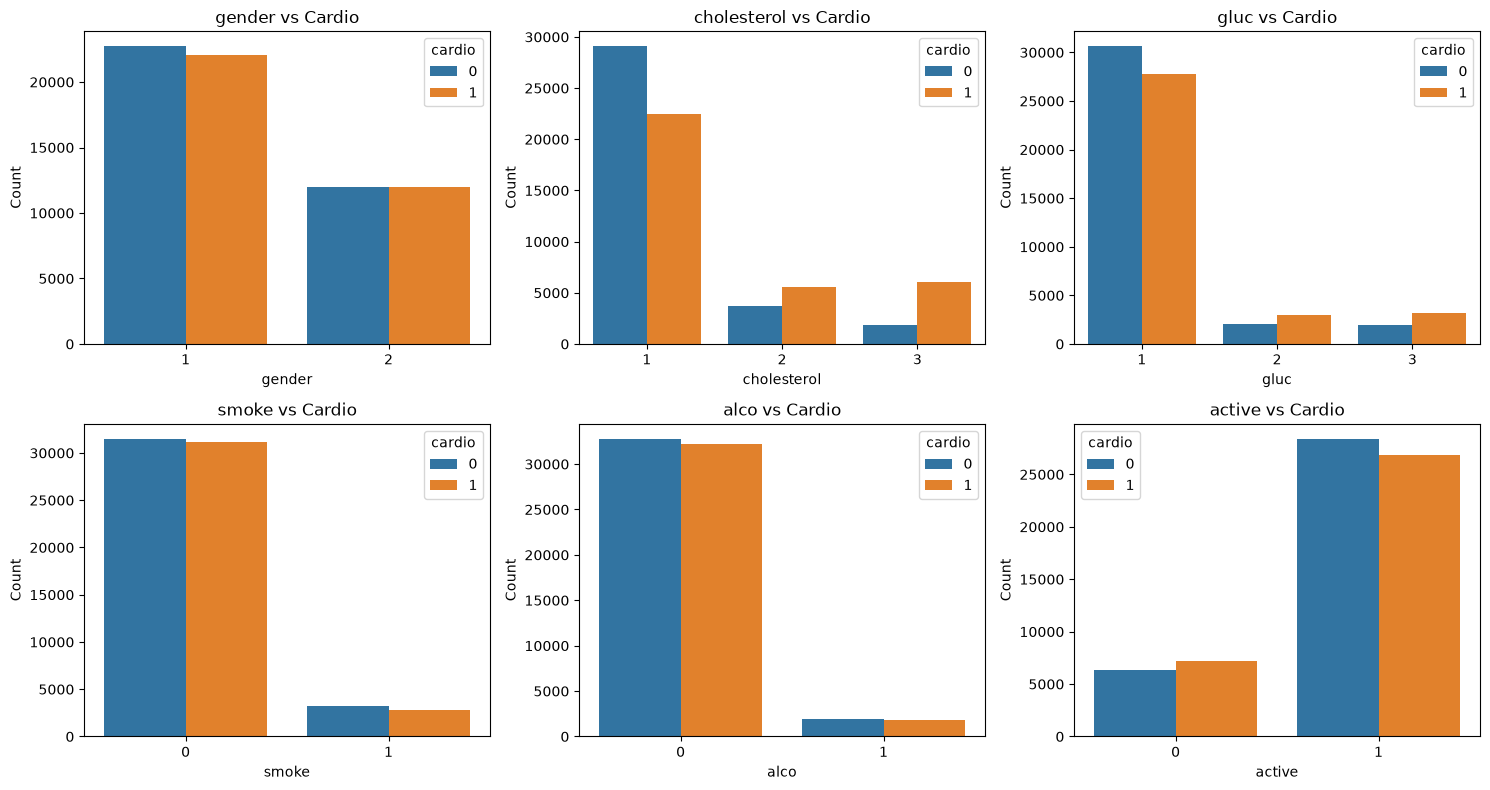

In [14]:
categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        hue="cardio",
        ax=ax
    )
    
    ax.set_title(f"{feature} vs Cardio")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Correlation Heatmap

The correlation matrix is used to examine the relationships between the numerical features and identify features that may have stronger associations with the target variable cardio.

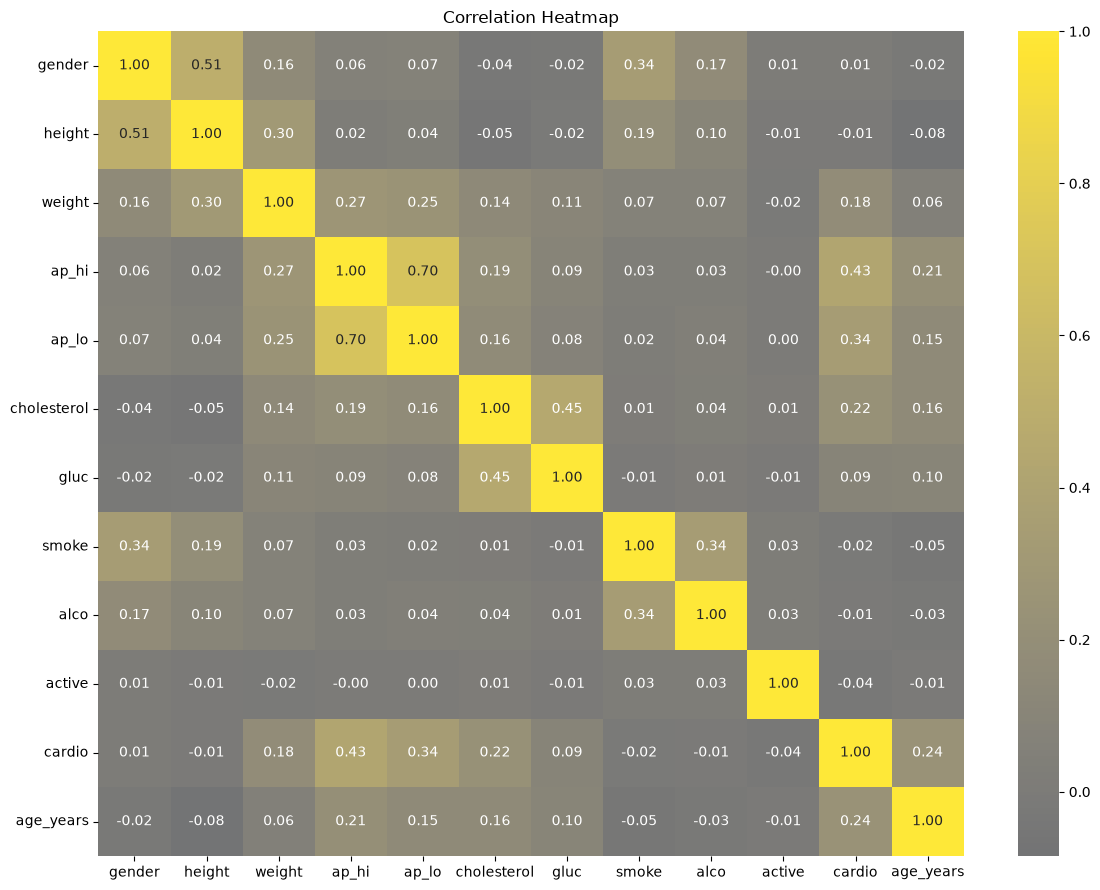

In [15]:
correlation_data = df.drop(columns=["id"])

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="cividis",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## EDA Findings

The exploratory data analysis revealed several important patterns in the cardiovascular disease dataset:

- The target variable cardio contains two classes: patients with and without cardiovascular disease.
- Age, weight, systolic blood pressure (ap_hi), and diastolic blood pressure (ap_lo) show noticeable differences between the two target classes.
- Blood pressure features, particularly ap_hi, show a relatively strong relationship with cardiovascular disease.
- Cholesterol and glucose levels show differences across the cardiovascular disease groups.
- The remaining categorical features, including smoking, alcohol consumption, and physical activity, show varying distributions between the two classes.
- The correlation analysis provides an initial understanding of the relationships between features and the target variable.

These findings will guide the feature selection and preprocessing steps used in the baseline model.